# Broad and narrow qubit spectroscopy

Load the spectroscopy bundles from `data/broad_spec`, plot the narrow and broadened spectra versus qubit drive frequency, and save the figure.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from bundle_utils import amp_prefactor_to_rabi_amp_mhz, extract_qubit_variables
from presentation_style import polish_axes, presentation_figure, use_presentation_style

use_presentation_style()

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "broad_spec"
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def lorentzian(x, offset, amplitude, center, gamma):
    return offset + amplitude / (1 + ((x - center) / gamma) ** 2)

def fit_lorentzian(x, y):
    offset0 = float(np.nanmin(y))
    amplitude0 = float(np.nanmax(y) - offset0)
    center0 = float(x[int(np.nanargmax(y))])
    gamma0 = max(float((x.max() - x.min()) / 20), 1e-5)
    lower = [0, 0, float(x.min()), 1e-6]
    upper = [1.5, 2.0, float(x.max()), float(x.max() - x.min())]
    popt, _ = curve_fit(
        lorentzian,
        x,
        y,
        p0=[offset0, amplitude0, center0, gamma0],
        bounds=(lower, upper),
        maxfev=20000,
    )
    return popt

bundle_paths = sorted(DATA_DIR.glob("*_data_bundle.npz"))
if not bundle_paths:
    raise FileNotFoundError(f"No data bundles found in {DATA_DIR}")

spectra = []
for path in bundle_paths:
    data = extract_qubit_variables(path)
    amp_factor = data.parameters.get("operation_amplitude_factor", np.nan)
    operation = data.parameters.get("operation", "saturation")
    operation_amp = data.profile_pulses[data.qubit_name][operation]["amplitude"]
    drive_amp = operation_amp * amp_factor
    drive_amp_mhz = float(
        amp_prefactor_to_rabi_amp_mhz(
            drive_amp,
            data.pi_pulse["amplitude"],
            data.pi_pulse["length_ns"],
        )
    )
    fit_params = fit_lorentzian(data.drive_frequency_ghz, data.result)
    spectra.append(
        {
            "path": path,
            "data": data,
            "amp_factor": amp_factor,
            "operation_amp": operation_amp,
            "drive_amp": drive_amp,
            "drive_amp_mhz": drive_amp_mhz,
            "fit_params": fit_params,
            "max_index": int(np.nanargmax(data.result)),
            "min_index": int(np.nanargmin(data.result)),
        }
    )

spectra = sorted(spectra, key=lambda item: item["drive_amp_mhz"])
for index, item in enumerate(spectra):
    if index == 0:
        item["label"] = "Narrow"
    elif index == len(spectra) - 1:
        item["label"] = "Broad"
    else:
        item["label"] = f"Spec {index + 1}"

[(item["label"], item["path"].name, item["drive_amp_mhz"], item["fit_params"][2]) for item in spectra]

[('Narrow',
  '03a_qubit_spectroscopy_08-17-03-886564_data_bundle.npz',
  0.38677087558311285,
  4.267082511325408),
 ('Broad',
  '03a_qubit_spectroscopy_08-28-37-326941_data_bundle.npz',
  9.66927188957782,
  4.26686368277637)]

In [2]:
for item in spectra:
    data = item["data"]
    offset, amplitude, center, gamma = item["fit_params"]
    print(f"{item['label']}: {item['path']}")
    print(f"  Qubit: {data.qubit_name}")
    print(f"  Qubit f01: {data.qubit_f01_hz / 1e9:.6f} GHz")
    print(f"  Operation amplitude factor: {item['amp_factor']}")
    print(f"  Drive amplitude: {item['drive_amp_mhz']:.3f} MHz")
    print(f"  Frequency range: {data.drive_frequency_ghz.min():.6f} to {data.drive_frequency_ghz.max():.6f} GHz")
    print(f"  State range: {data.result.min():.4f} to {data.result.max():.4f}")
    print(f"  Fit center: {center:.6f} GHz, width: {gamma * 1000:.3f} MHz")

Narrow: c:\Users\owner\Developer\ips_plots\data\broad_spec\03a_qubit_spectroscopy_08-17-03-886564_data_bundle.npz
  Qubit: q1
  Qubit f01: 4.267107 GHz
  Operation amplitude factor: 0.01
  Drive amplitude: 0.387 MHz
  Frequency range: 4.217107 to 4.317007 GHz
  State range: 0.0400 to 0.5620
  Fit center: 4.267083 GHz, width: 0.539 MHz
Broad: c:\Users\owner\Developer\ips_plots\data\broad_spec\03a_qubit_spectroscopy_08-28-37-326941_data_bundle.npz
  Qubit: q1
  Qubit f01: 4.267107 GHz
  Operation amplitude factor: 0.25
  Drive amplitude: 9.669 MHz
  Frequency range: 4.217107 to 4.317007 GHz
  State range: 0.0560 to 0.5860
  Fit center: 4.266864 GHz, width: 7.994 MHz


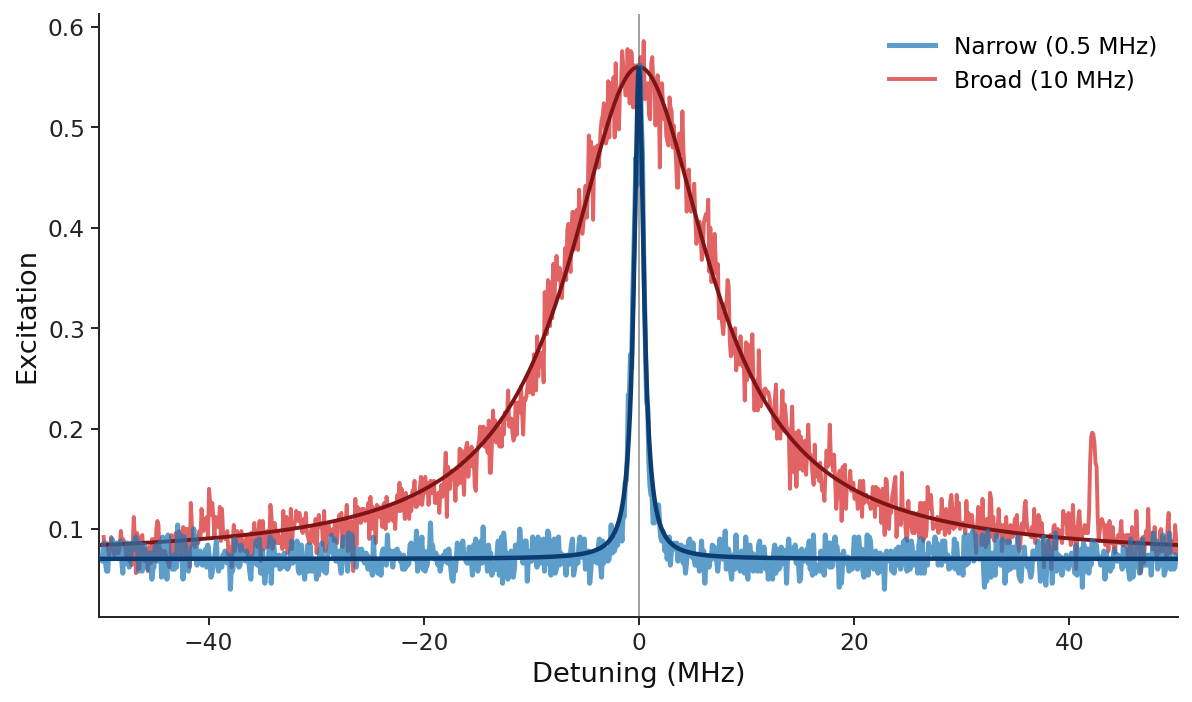

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\02_broad_and_narrow_spec_q1.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\02_broad_and_narrow_spec_q1.pdf
Narrow max state: 0.5620 at 0.124 MHz from fitted center; fit center: 4.267083 GHz
Broad max state: 0.5860 at 0.443 MHz from fitted center; fit center: 4.266864 GHz


In [3]:
fig, ax = presentation_figure(width=8.4, height=4.9)
colors = {"Narrow": "#1f77b4", "Broad": "#d62728"}
fit_colors = {"Narrow": "#0b3d73", "Broad": "#7f1416"}

half_span_mhz = max(
    float(np.max(np.abs((item["data"].drive_frequency_ghz - item["fit_params"][2]) * 1000)))
    for item in spectra
)
fit_frequency_relative_mhz = np.linspace(-half_span_mhz, half_span_mhz, 2000)

plot_order = sorted(spectra, key=lambda item: item["label"] == "Narrow")
for item in plot_order:
    data = item["data"]
    center_ghz = item["fit_params"][2]
    frequency_relative_mhz = (data.drive_frequency_ghz - center_ghz) * 1000
    fit_frequency_ghz = center_ghz + fit_frequency_relative_mhz / 1000
    legend_amp_mhz = 0.5 if item["label"] == "Narrow" else 10 if item["label"] == "Broad" else item["drive_amp_mhz"]
    label = f"{item['label']} ({legend_amp_mhz:g} MHz)"
    color = colors.get(item["label"])
    fit_color = fit_colors.get(item["label"])
    is_narrow = item["label"] == "Narrow"
    z_base = 4 if is_narrow else 2
    ax.plot(
        frequency_relative_mhz,
        data.result,
        linewidth=2.6 if is_narrow else 2.0,
        label=label,
        color=color,
        alpha=0.72,
        zorder=z_base,
    )
    ax.plot(
        fit_frequency_relative_mhz,
        lorentzian(fit_frequency_ghz, *item["fit_params"]),
        linewidth=2.3 if is_narrow else 2.0,
        color=fit_color,
        zorder=z_base + 1,
    )

ax.axvline(0, color="#555555", linewidth=1.0, alpha=0.55)
ax.set_xlim(-half_span_mhz, half_span_mhz)
ax.set_xlabel("Detuning (MHz)")
ax.set_ylabel("Excitation")
handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: 0 if labels[i].startswith("Narrow") else 1)
ax.legend([handles[i] for i in order], [labels[i] for i in order], loc="best")
polish_axes(ax)

qubit_name = spectra[0]["data"].qubit_name
figure_stem = FIGURES_DIR / f"02_broad_and_narrow_spec_{qubit_name}"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.canvas.draw()
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")
for item in spectra:
    data = item["data"]
    max_index = item["max_index"]
    center = item["fit_params"][2]
    max_relative_mhz = (data.drive_frequency_ghz[max_index] - center) * 1000
    print(f"{item['label']} max state: {data.result[max_index]:.4f} at {max_relative_mhz:.3f} MHz from fitted center; fit center: {center:.6f} GHz")